# Digit Classification using Dense Neural Network (DNN) - Version 2
 - Using validation and test data

## ==> Verify on Runtime tab if GPU is active on Runtime type

## Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

## Upload and Explore Dataset
[MNIST](http://yann.lecun.com/exdb/mnist/) handwritten digits dataset

The MNIST database of handwritten digits, is also available from this [TF page](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data), has a training set of 60,000 28x28 grayscale images of the 10 digits along a test set of 10,000 images. It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image.


In [3]:
data = tf.keras.datasets.mnist

(tt_images, tt_labels), (test_images, test_labels) = data.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
print(tt_images.shape)
print(tt_labels.shape)

(60000, 28, 28)
(60000,)


In [5]:
print(test_images.shape)
print(test_labels.shape)

(10000, 28, 28)
(10000,)


In [6]:
tt_labels[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

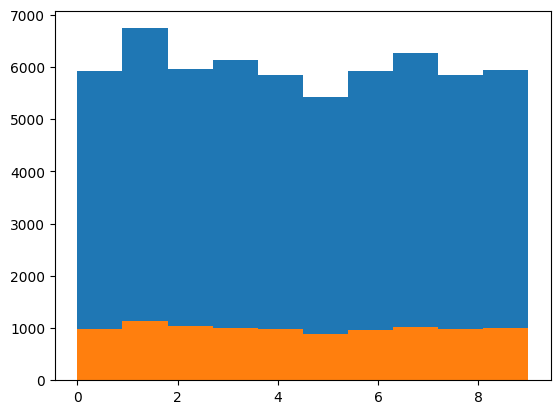

In [7]:
plt.hist(tt_labels);
plt.hist(test_labels);

In [8]:
val_images = tt_images[:10000]
val_labels = tt_labels[:10000]

In [9]:
train_images = tt_images[10000:]
train_labels = tt_labels[10000:]

In [10]:
print(train_images.shape)
print(train_labels.shape)

(50000, 28, 28)
(50000,)


In [11]:
print(val_images.shape)
print(val_labels.shape)

(10000, 28, 28)
(10000,)


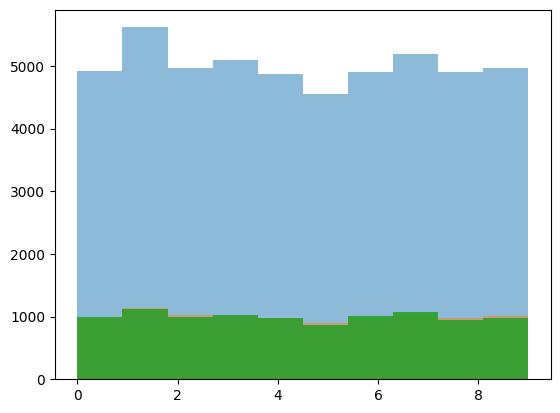

In [12]:
plt.hist(train_labels, alpha=0.5, label='Train')
plt.hist(test_labels, alpha=0.5, label='Val')
plt.hist(val_labels, alpha=0.9, label='Test');


     Label of image 1000 is: 9
O label da imagem de teste número 1000 é 9


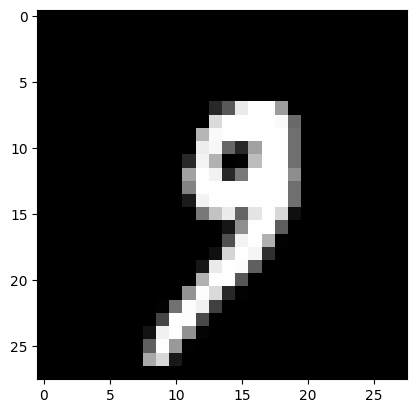

In [13]:
img = 1000
print("     Label of image {} is: {}".format(img, test_labels[img]))
print(f"O label da imagem de teste número {img} é {test_labels[img]}")
plt.imshow(test_images[img], cmap='gray');

### Preprocessing Data

**Normalizing Data**:
We notice that all of the values in the number are between 0 and 255. If we are training a neural network, for various reasons it's easier if we treat all values as between 0 and 1, a process called 'normalizing'.

In [14]:
train_images  = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

## Define and Compile Model

In [15]:
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(input_shape=(28,28)),
                                    tf.keras.layers.Dense(20, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [18]:
model = Sequential([Flatten(input_shape=(28,28)),
                    Dense(20, activation='relu'),
                    Dense(10, activation='softmax')])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
#model.add(Dense(20, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
def create_model():
  model = Sequential()
  model.add(Flatten(input_shape=(28,28)))
  model.add(Dense(20, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

In [21]:
model = create_model()

In [22]:
model.compile(
    optimizer='adam', # uses default learning_rate=0.001
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

In [23]:
from tensorflow.keras.optimizers import Adam, SGD

In [41]:
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

## Train the model

You could leave the training data with all samples, and alternativelly use:
- `validation_split=0.1` instead of `validation_data=(val_images, val_labels)`.

In this case, TF will split the validation data by itself.

In [42]:
history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    validation_data=(val_images, val_labels)
    )

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9042 - loss: 0.3208 - val_accuracy: 0.9178 - val_loss: 0.2749
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9343 - loss: 0.2248 - val_accuracy: 0.9404 - val_loss: 0.2153
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9398 - loss: 0.2018 - val_accuracy: 0.9361 - val_loss: 0.2277
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9430 - loss: 0.1929 - val_accuracy: 0.9391 - val_loss: 0.2294
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9467 - loss: 0.1808 - val_accuracy: 0.9457 - val_loss: 0.2033
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9476 - loss: 0.1761 - val_accuracy: 0.9441 - val_loss: 0.2157
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9491 - loss: 0.1731 - val_accuracy: 0.9233 - val_loss: 0.2868
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9510 - loss: 0.1667 - 

Inspecting the model

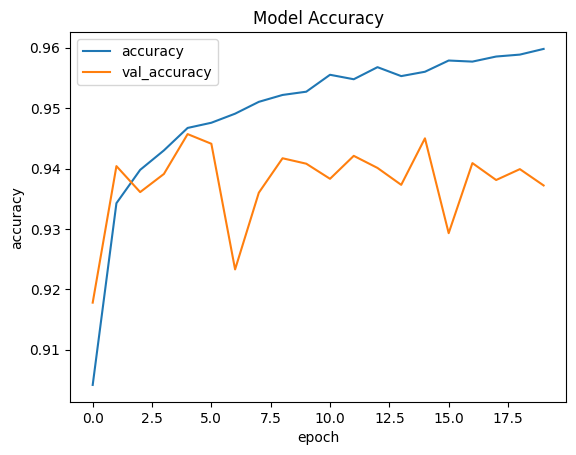

{'accuracy': [0.9041799902915955, 0.9342600107192993, 0.9397799968719482, 0.9430000185966492, 0.9467200040817261, 0.9475799798965454, 0.9490799903869629, 0.9510400295257568, 0.952180027961731, 0.9527199864387512, 0.95551997423172, 0.9547799825668335, 0.9567800164222717, 0.955299973487854, 0.9560199975967407, 0.9578800201416016, 0.9577000141143799, 0.9585400223731995, 0.9588599801063538, 0.9598000049591064], 'loss': [0.3207567036151886, 0.224765345454216, 0.20181125402450562, 0.19293755292892456, 0.1808023601770401, 0.17610876262187958, 0.1731119155883789, 0.166743203997612, 0.16465726494789124, 0.15906032919883728, 0.15319184958934784, 0.15519575774669647, 0.15086787939071655, 0.14917752146720886, 0.14905358850955963, 0.14249294996261597, 0.14235687255859375, 0.14022935926914215, 0.13787943124771118, 0.13710585236549377], 'val_accuracy': [0.9178000092506409, 0.9404000043869019, 0.9361000061035156, 0.9391000270843506, 0.9456999897956848, 0.944100022315979, 0.92330002784729, 0.9359999895

In [43]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.show()
print(history.history)

If validation accuracy seems “instable”, could be that Learning Rate is high (try to reduce it).

Let's start over with a lower Lr (for exampe: 0.0001)

In [45]:
model = create_model()
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    validation_data=(val_images, val_labels)
    )

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6878 - loss: 1.1883 - val_accuracy: 0.8542 - val_loss: 0.6233
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8726 - loss: 0.5098 - val_accuracy: 0.8925 - val_loss: 0.4226
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8947 - loss: 0.3941 - val_accuracy: 0.9045 - val_loss: 0.3597
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9047 - loss: 0.3475 - val_accuracy: 0.9087 - val_loss: 0.3278
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9108 - loss: 0.3203 - val_accuracy: 0.9146 - val_loss: 0.3093
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9150 - loss: 0.3017 - val_accuracy: 0.9177 - val_loss: 0.2930
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9203 - loss: 0.2876 - val_accuracy: 0.9212 - val_loss: 0.2820
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9229 - loss: 0.2757 - 

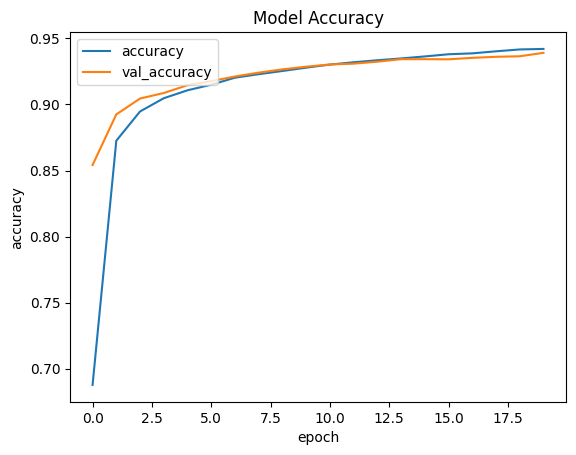

In [46]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper left')
plt.show()

## Testing the trained model


In [47]:
model.evaluate(train_images, train_labels)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9431 - loss: 0.2047


[0.20466528832912445, 0.9430599808692932]

In [48]:
model.evaluate(val_images, val_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9391 - loss: 0.2158


[0.21578291058540344, 0.9391000270843506]

In [49]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9400 - loss: 0.2123


[0.21234895288944244, 0.9399999976158142]

**Accuracy**
- Train: 0.97;
- Validation: 0.96
- Test: 0.95

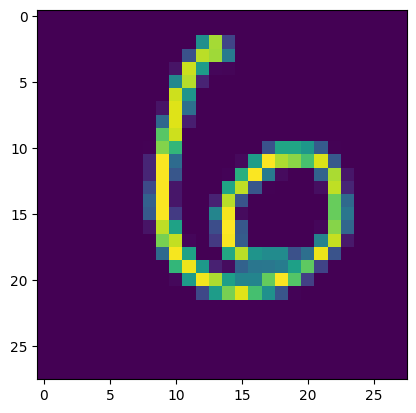

In [60]:
plt.imshow(test_images[100]);
#for i in range(5):
#    plt.imshow(test_images[i])

In [53]:
print(test_labels[100])

6


In [65]:
predictions = model.predict(test_images)
print(predictions[100])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[1.5564448e-04 9.2583714e-06 1.4275374e-02 1.2119852e-03 1.8518897e-04
 9.8230885e-05 9.8201674e-01 2.5279351e-04 1.3458126e-03 4.4907632e-04]


In [66]:
# Returns the indices of the maximum values along an axis.
np.argmax(predictions[0])

np.int64(7)

In [67]:
predictions = np.argmax(predictions, axis=-1)
predictions.shape

(10000,)

In [68]:
predictions[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 6, 9])

In [73]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(test_labels, predictions))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.97      0.98      0.98      1135
           2       0.93      0.93      0.93      1032
           3       0.90      0.93      0.92      1010
           4       0.94      0.95      0.95       982
           5       0.94      0.89      0.91       892
           6       0.95      0.95      0.95       958
           7       0.94      0.93      0.94      1028
           8       0.93      0.91      0.92       974
           9       0.93      0.93      0.93      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



In [74]:
confusion_matrix(test_labels,predictions)

array([[ 964,    0,    1,    2,    0,    5,    4,    3,    1,    0],
       [   0, 1116,    4,    1,    0,    0,    3,    2,    9,    0],
       [   4,    7,  955,   20,    8,    4,    9,    7,   15,    3],
       [   3,    0,   20,  944,    0,    9,    1,   13,   14,    6],
       [   2,    1,    5,    0,  935,    0,    8,    3,    3,   25],
       [   7,    3,    3,   36,    7,  791,   11,    7,   19,    8],
       [  14,    3,    6,    1,    7,   11,  912,    2,    2,    0],
       [   2,    7,   21,    6,    4,    2,    0,  957,    2,   27],
       [   4,    4,    7,   25,    8,   13,    8,   11,  888,    6],
       [   9,    6,    1,   15,   21,    4,    1,   10,    4,  938]])

In [75]:
!pip install seaborn

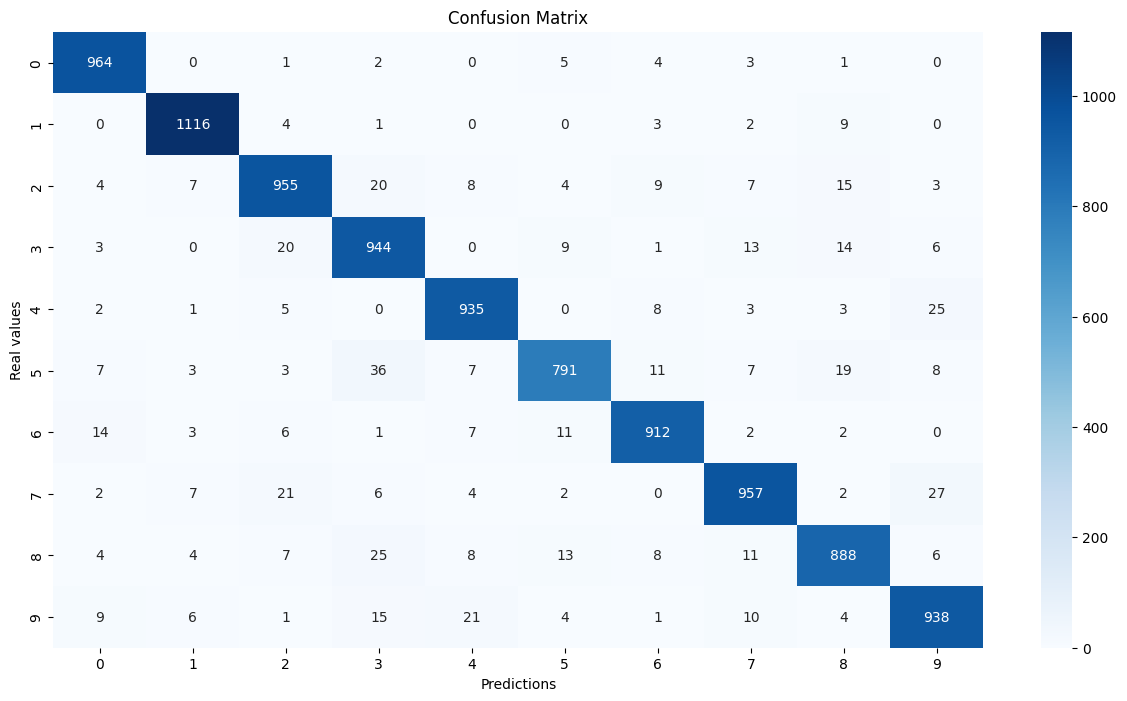

In [76]:
import seaborn as sns
plt.figure(figsize=(15,8))
sns.heatmap(confusion_matrix(test_labels,predictions), cmap="Blues", annot=True, fmt='g');
plt.title('Confusion Matrix')
plt.xlabel("Predictions")
plt.ylabel("Real values")
plt.show()

In [77]:
model.save('MNIST_v2_model.h5')

Use [Netron](https://netron.app) to visualize the model, hyperparameters, tensor shapes, etc. Netron is a viewer for neural network, deep learning and machine learning models (See [GitHub](https://github.com/lutzroeder/netron) for instructions about instalation in your desktop).